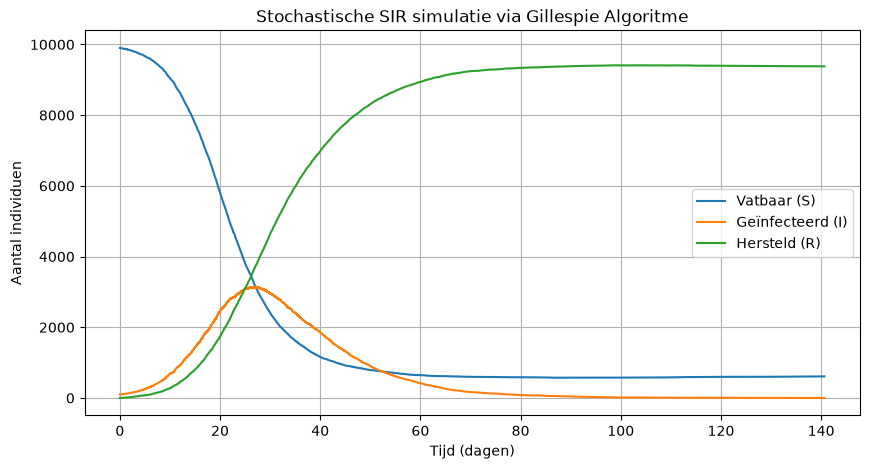

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Stochastic Model

def gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max):
    # Initiële waarden
    t = 0.0
    X, Y, Z = X0, Y0, Z0
    
    # Lijsten voor de resultaten
    times = [t]
    X_history = [X]
    Y_history = [Y]
    Z_history = [Z]
    
    while t < t_max and Y > 0:
        # Bereken de rates (propensities) van elke gebeurtenis
        r1 = mu * N                  # Geboorte (X -> X + 1)
        r2 = beta * X * Y / N        # Infectie (X -> X-1, Y -> Y+1)
        r3 = gamma * Y               # Herstel (Y -> Y-1, Z -> Z+1)
        r4 = mu * X                  # Sterfte S (X -> X - 1)
        r5 = mu * Y                  # Sterfte I (Y -> Y - 1)
        r6 = mu * Z                  # Sterfte R (Z -> Z - 1)
        
        rates = [r1, r2, r3, r4, r5, r6]
        R_total = sum(rates)
        
        if R_total == 0:
            break
            
        # 1. Bepaal de tijd tot de volgende gebeurtenis (Exponentiële verdeling)
        u1 = np.random.uniform(0, 1)
        dt = -np.log(u1) / R_total
        t += dt
        
        # 2. Bepaal welke gebeurtenis plaatsvindt
        u2 = np.random.uniform(0, 1)
        probabilities = [r / R_total for r in rates]
        event = np.random.choice(6, p=probabilities)
        
        # 3. Voer de gekozen gebeurtenis uit
        if event == 0:    # Geboorte
            X += 1
        elif event == 1:  # Infectie
            X -= 1
            Y += 1
        elif event == 2:  # Herstel
            Y -= 1
            Z += 1
        elif event == 3:  # Sterfte X
            X -= 1
        elif event == 4:  # Sterfte Y
            Y -= 1
        elif event == 5:  # Sterfte Z
            Z -= 1
            
        # Bewaar de toestand
        times.append(t)
        X_history.append(X)
        Y_history.append(Y)
        Z_history.append(Z)
        
    return np.array(times), np.array(X_history), np.array(Y_history), np.array(Z_history)

# Voorbeeld van een simulatie run:
N = 10000
R0 = 3.0
gamma = 1/10  
beta = R0 * gamma
mu = 0.0001   

X0, Y0, Z0 = 9900, 100, 0
t_max = 365

times, X, Y, Z = gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max)

# Plotten
plt.figure(figsize=(10, 5))
plt.plot(times, X, label='Vatbaar (S)')
plt.plot(times, Y, label='Geïnfecteerd (I)')
plt.plot(times, Z, label='Hersteld (R)')
plt.xlabel('Tijd (dagen)')
plt.ylabel('Aantal individuen')
plt.title('Stochastische SIR simulatie via Gillespie Algoritme')
plt.legend()
plt.grid(True)
plt.show()

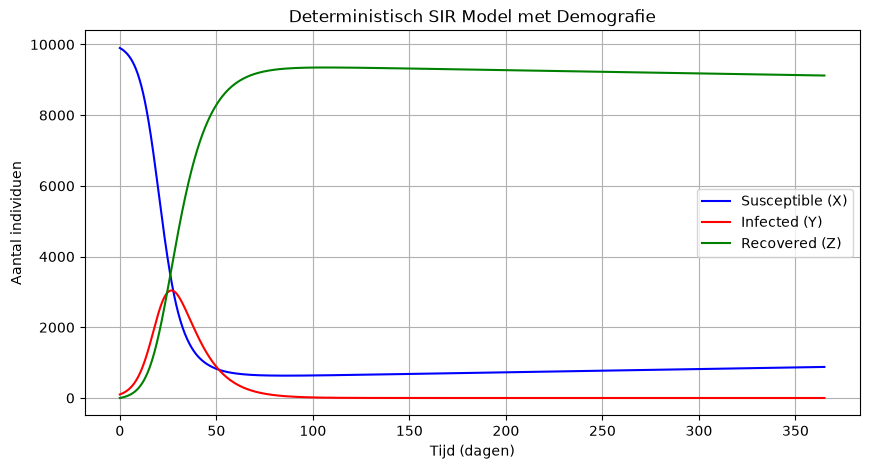

In [2]:
# Deterministic Model

from scipy.integrate import solve_ivp

def sir_deterministic(t, y, N, beta, gamma, mu):
    X, Y, Z = y
    
    # Differential equations for absolute numbers X, Y, Z
    dX_dt = mu * N - (beta * X * Y / N) - mu * X
    dY_dt = (beta * X * Y / N) - gamma * Y - mu * Y
    dZ_dt = gamma * Y - mu * Z
    
    return [dX_dt, dY_dt, dZ_dt]

# Model parameters
N = 10000        
beta = 0.3      
gamma = 0.1     
mu = 0.0001      

# Initiële aantallen (X0 + Y0 + Z0 = N)
X0 = 9900
Y0 = 100
Z0 = 0
y0 = [X0, Y0, Z0]

# Tijdsdomein
t_span = (0, 365)
t_eval = np.linspace(t_span[0], t_span[1], 2000)

# Oplossen van de ODE
solution = solve_ivp(
    sir_deterministic, 
    t_span, 
    y0, 
    args=(N, beta, gamma, mu), 
    t_eval=t_eval
)

# Plotten
plt.figure(figsize=(10, 5))
plt.plot(solution.t, solution.y[0], label='Susceptible (X)', color='blue')
plt.plot(solution.t, solution.y[1], label='Infected (Y)', color='red')
plt.plot(solution.t, solution.y[2], label='Recovered (Z)', color='green')
plt.title('Deterministisch SIR Model met Demografie')
plt.xlabel('Tijd (dagen)')
plt.ylabel('Aantal individuen')
plt.legend()
plt.grid(True)
plt.show()

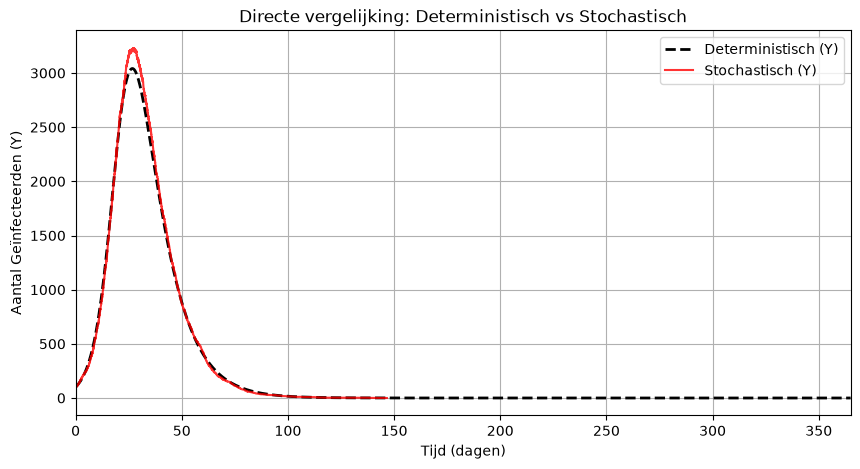

In [3]:
# De 2 modellen samen plotten

# Parameters die exact gelijk zijn voor beide modellen:
N = 10000
beta = 0.3
gamma = 0.1
mu = 0.0001

X0, Y0, Z0 = 9900, 100, 0
t_max = 365  

# 1. Deterministische oplossing
t_eval = np.linspace(0, t_max, 1000)
sol = solve_ivp(sir_deterministic, (0, t_max), [X0, Y0, Z0], args=(N, beta, gamma, mu), t_eval=t_eval)

# 2. Stochastische oplossing (Gillespie)
t_gillespie, X_g, Y_g, Z_g = gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max)

# 3. Plotten in één figuur
plt.figure(figsize=(10, 5))

# Deterministisch
plt.plot(sol.t, sol.y[1], color='black', linewidth=2, linestyle='--', label='Deterministisch (Y)')

# Stochastisch
plt.plot(t_gillespie, Y_g, color='red', alpha=0.8, label='Stochastisch (Y)')

plt.xlim(0, t_max)
plt.xlabel('Tijd (dagen)')
plt.ylabel('Aantal Geïnfecteerden (Y)')
plt.title('Directe vergelijking: Deterministisch vs Stochastisch')
plt.legend()
plt.grid(True)
plt.show()

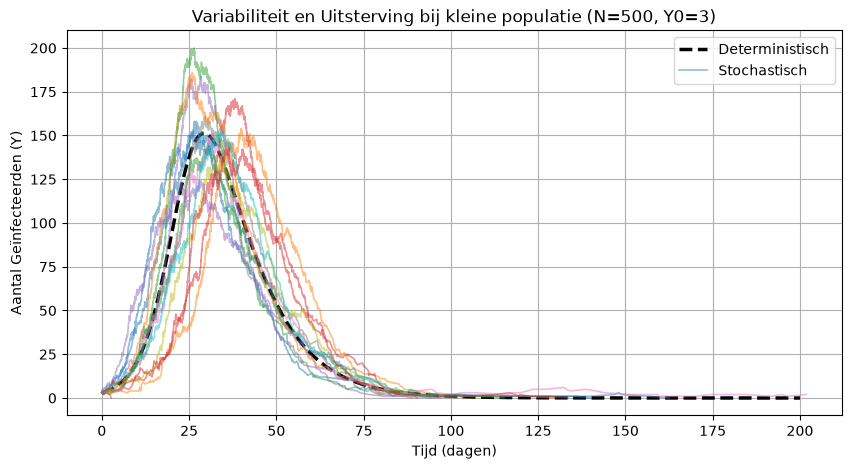

In [4]:
# Simulatie met kleinere populatie N
N = 500
beta = 0.3
gamma = 0.1
mu = 0.0001
X0, Y0, Z0 = 497, 3, 0  
t_max = 200

# Plot deterministisch
t_eval = np.linspace(0, t_max, 1000)
sol = solve_ivp(sir_deterministic, (0, t_max), [X0, Y0, Z0], args=(N, beta, gamma, mu), t_eval=t_eval)

plt.figure(figsize=(10, 5))
plt.plot(sol.t, sol.y[1], color='black', linewidth=2.5, linestyle='--', label='Deterministisch')

# Plot meerdere stochastische runs
for i in range(15):
    t_gillespie, X_g, Y_g, Z_g = gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max)
    plt.plot(t_gillespie, Y_g, alpha=0.5, linewidth=1.2, label='Stochastisch' if i == 0 else "")

plt.xlabel('Tijd (dagen)')
plt.ylabel('Aantal Geïnfecteerden (Y)')
plt.title('Variabiliteit en Uitsterving bij kleine populatie (N=500, Y0=3)')
plt.legend()
plt.grid(True)
plt.show()

Evenwicht: X* = 10137, Y* = 539


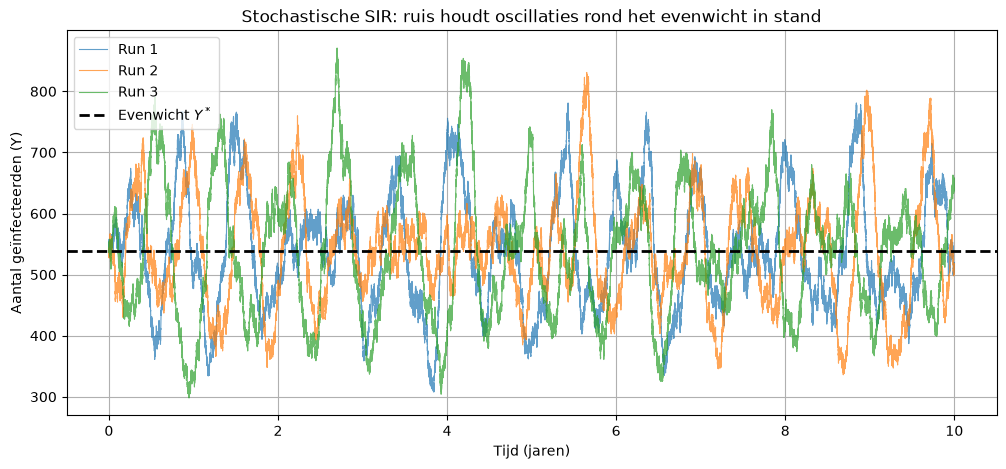

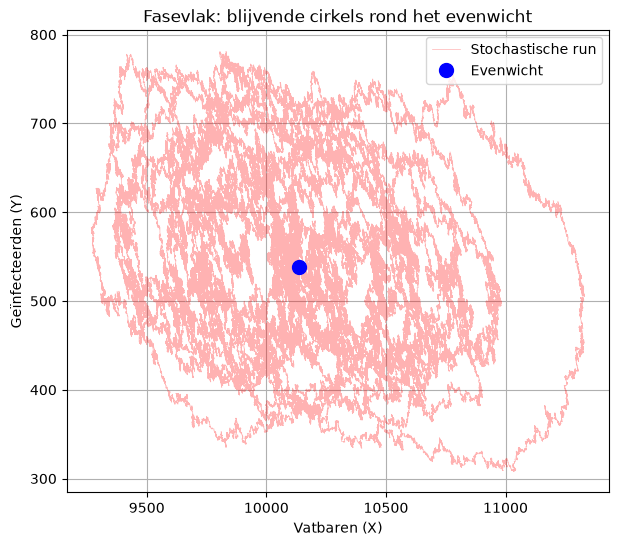

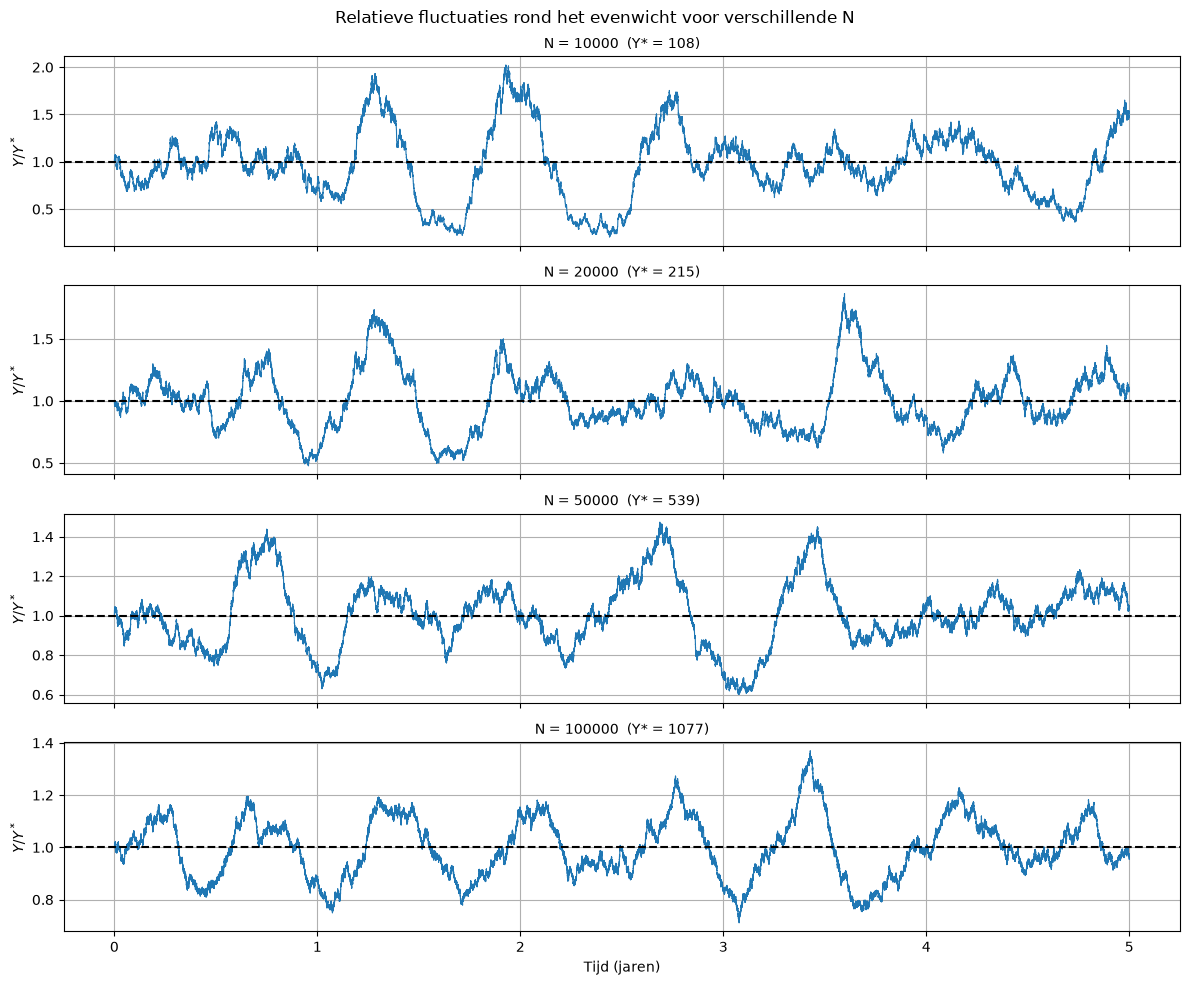

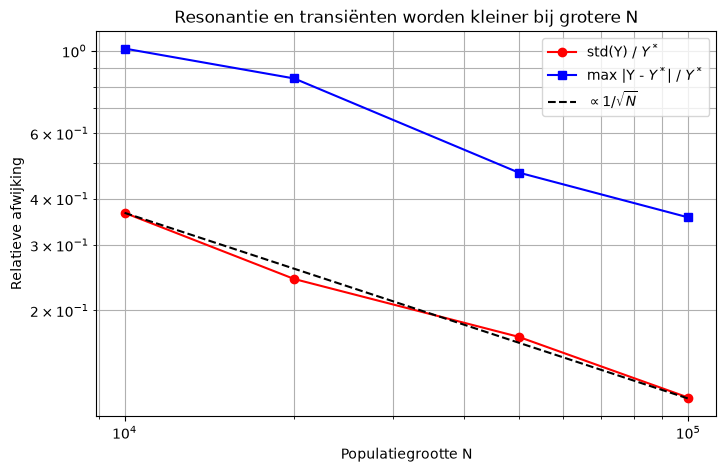

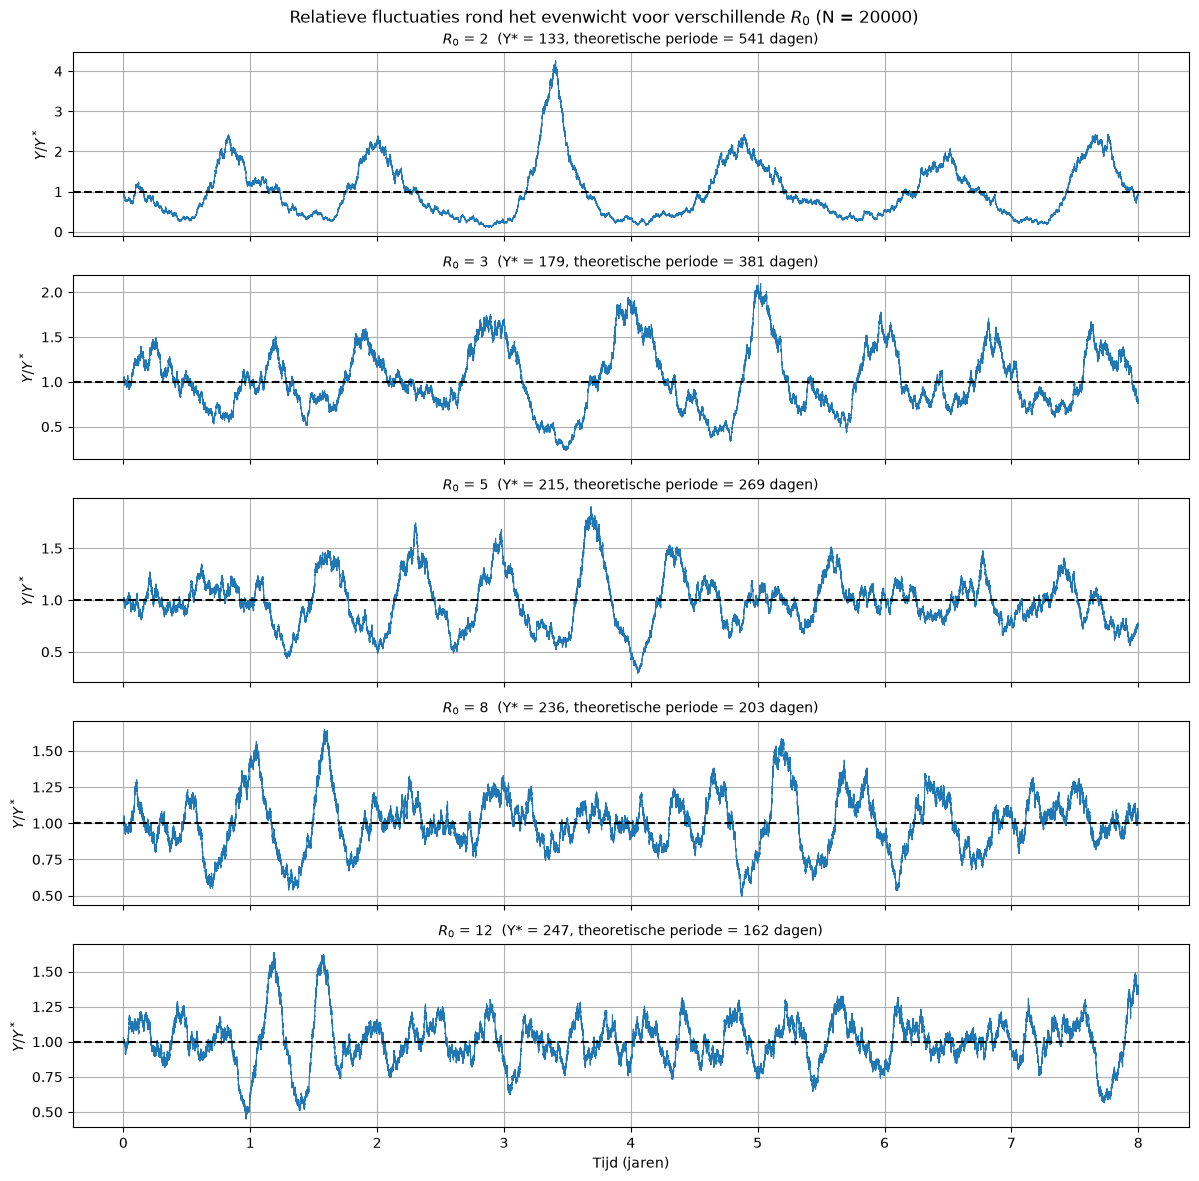

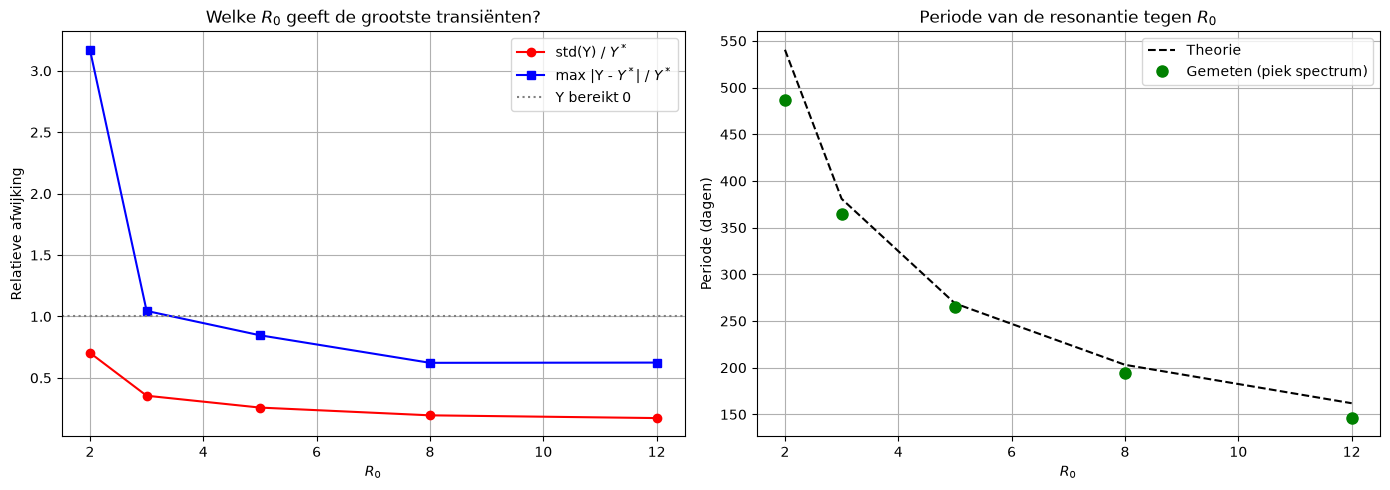


N        std/Y*   max afw/Y*
10000    0.366    1.01
20000    0.243    0.84
50000    0.170    0.47
100000   0.117    0.36

R0   std/Y*   max afw/Y*   T gemeten   T theorie
2    0.704    3.17            487         541
3    0.355    1.05            365         381
5    0.258    0.85            266         269
8    0.195    0.62            195         203
12   0.173    0.62            146         162


In [10]:
# Stochastic resonance

import numpy as np
import matplotlib.pyplot as plt

# Stochastic Model

def gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max):
    # Initiële waarden
    t = 0.0
    X, Y, Z = X0, Y0, Z0
    
    # Lijsten voor de resultaten
    times = [t]
    X_history = [X]
    Y_history = [Y]
    Z_history = [Z]
    
    while t < t_max and Y > 0:
        # Bereken de rates (propensities) van elke gebeurtenis
        r1 = mu * N                  # Geboorte (X -> X + 1)
        r2 = beta * X * Y / N        # Infectie (X -> X-1, Y -> Y+1)
        r3 = gamma * Y               # Herstel (Y -> Y-1, Z -> Z+1)
        r4 = mu * X                  # Sterfte S (X -> X - 1)
        r5 = mu * Y                  # Sterfte I (Y -> Y - 1)
        r6 = mu * Z                  # Sterfte R (Z -> Z - 1)
        
        rates = [r1, r2, r3, r4, r5, r6]
        R_total = sum(rates)
        
        if R_total == 0:
            break
            
        # 1. Bepaal de tijd tot de volgende gebeurtenis (Exponentiële verdeling)
        u1 = np.random.uniform(0, 1)
        dt = -np.log(u1) / R_total
        t += dt
        
        # 2. Bepaal welke gebeurtenis plaatsvindt
        u2 = np.random.uniform(0, 1)
        probabilities = [r / R_total for r in rates]
        event = np.random.choice(6, p=probabilities)
        
        # 3. Voer de gekozen gebeurtenis uit
        if event == 0:    # Geboorte
            X += 1
        elif event == 1:  # Infectie
            X -= 1
            Y += 1
        elif event == 2:  # Herstel
            Y -= 1
            Z += 1
        elif event == 3:  # Sterfte X
            X -= 1
        elif event == 4:  # Sterfte Y
            Y -= 1
        elif event == 5:  # Sterfte Z
            Z -= 1
            
        # Bewaar de toestand
        times.append(t)
        X_history.append(X)
        Y_history.append(Y)
        Z_history.append(Z)
        
    return np.array(times), np.array(X_history), np.array(Y_history), np.array(Z_history)

# Voorbeeld van een simulatie run:

N = 50000
R0 = 5.0
gamma = 1/10
beta = R0 * gamma
mu = 1/(2*365)

# Endemisch evenwicht
X_eq = N * (gamma + mu) / beta
Y_eq = mu * N * (N - X_eq) / (beta * X_eq)
print(f"Evenwicht: X* = {X_eq:.0f}, Y* = {Y_eq:.0f}")

# Beginwaarden instellen in evenwicht
X0 = int(round(X_eq))
Y0 = int(round(Y_eq))
Z0 = N - X0 - Y0
t_max = 10 * 365

# Een paar runs uitvoeren
n_runs = 3
runs = []
for i in range(n_runs):
    runs.append(gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max))
    if runs[-1][0][-1] < t_max:
        print(f"Run {i+1} is uitgestorven na {runs[-1][0][-1]/365:.1f} jaar")

# Plot tegenover verwacht evenwicht
plt.figure(figsize=(12, 5))
for i, (t_s, X_s, Y_s, Z_s) in enumerate(runs):
    plt.plot(t_s / 365, Y_s, alpha=0.7, lw=0.8, label=f'Run {i+1}')
plt.axhline(Y_eq, color='k', ls='--', lw=2, label='Evenwicht $Y^*$')
plt.xlabel('Tijd (jaren)')
plt.ylabel('Aantal geïnfecteerden (Y)')
plt.title('Stochastische SIR: ruis houdt oscillaties rond het evenwicht in stand')
plt.legend()
plt.grid(True)
plt.show()

# Plot de phase plot
t_s, X_s, Y_s, Z_s = runs[0]
plt.figure(figsize=(7, 6))
plt.plot(X_s, Y_s, color='red', alpha=0.3, lw=0.5, label='Stochastische run')
plt.plot(X_eq, Y_eq, 'bo', ms=10, label='Evenwicht')
plt.xlabel('Vatbaren (X)')
plt.ylabel('Geïnfecteerden (Y)')
plt.title('Fasevlak: blijvende cirkels rond het evenwicht')
plt.legend()
plt.grid(True)
plt.show()

# Experiment N: invloed van de populatiegrootte N (beta vast)
N_waarden = [10000, 20000, 50000, 100000]
t_max_scan = 5 * 365

rel_std_N = []
max_afw_N = []

fig, axes = plt.subplots(len(N_waarden), 1, figsize=(12, 10), sharex=True)
for ax, N_i in zip(axes, N_waarden):
    # Evenwicht voor deze N
    X_eq_i = N_i * (gamma + mu) / beta
    Y_eq_i = mu * N_i * (N_i - X_eq_i) / (beta * X_eq_i)
    X0_i = int(round(X_eq_i))
    Y0_i = int(round(Y_eq_i))
    Z0_i = N_i - X0_i - Y0_i

    t_s, X_s, Y_s, Z_s = gillespie_sir(N_i, beta, gamma, mu, X0_i, Y0_i, Z0_i, t_max_scan)

    # Omzetten naar 1 waarde per dag
    t_dag = np.arange(0, t_s[-1], 1.0)
    Y_dag = Y_s[np.searchsorted(t_s, t_dag, side='right') - 1]
    if t_s[-1] < t_max_scan:
        Y_dag = np.append(Y_dag, 0)
        print(f"N = {N_i}: uitgestorven na {t_s[-1]/365:.1f} jaar")

    rel_std_N.append(Y_dag.std() / Y_eq_i)
    max_afw_N.append(np.max(np.abs(Y_dag - Y_eq_i)) / Y_eq_i)

    # Relatief t.o.v. het evenwicht plotten, zodat alle N vergelijkbaar zijn
    ax.plot(t_s / 365, Y_s / Y_eq_i, lw=0.8)
    ax.axhline(1, color='k', ls='--')
    ax.set_ylabel('$Y / Y^*$')
    ax.set_title(f'N = {N_i}  (Y* = {Y_eq_i:.0f})', fontsize=10)
    ax.grid(True)
axes[-1].set_xlabel('Tijd (jaren)')
plt.suptitle('Relatieve fluctuaties rond het evenwicht voor verschillende N')
plt.tight_layout()
plt.show()

# Samenvatting: relatieve amplitude schaalt als 1/sqrt(N)
N_arr = np.array(N_waarden, dtype=float)
plt.figure(figsize=(8, 5))
plt.loglog(N_arr, rel_std_N, 'ro-', label='std(Y) / $Y^*$')
plt.loglog(N_arr, max_afw_N, 'bs-', label='max |Y - $Y^*$| / $Y^*$')
plt.loglog(N_arr, rel_std_N[0] * np.sqrt(N_arr[0] / N_arr), 'k--', label=r'$\propto 1/\sqrt{N}$')
plt.xlabel('Populatiegrootte N')
plt.ylabel('Relatieve afwijking')
plt.title('Resonantie en transiënten worden kleiner bij grotere N')
plt.legend()
plt.grid(True, which='both')
plt.show()


# Experiment R0: invloed van R0 (dus beta = R0 * gamma), N vast
N_vast = 20000
R0_waarden = [2, 3, 5, 8, 12]
t_max_scan = 8 * 365

rel_std_R = []
max_afw_R = []
T_gemeten = []
T_theorie = []

fig, axes = plt.subplots(len(R0_waarden), 1, figsize=(12, 12), sharex=True)
for ax, R0_i in zip(axes, R0_waarden):
    beta_i = R0_i * gamma
    X_eq_i = N_vast * (gamma + mu) / beta_i
    Y_eq_i = mu * N_vast * (N_vast - X_eq_i) / (beta_i * X_eq_i)
    X0_i = int(round(X_eq_i))
    Y0_i = int(round(Y_eq_i))
    Z0_i = N_vast - X0_i - Y0_i

    t_s, X_s, Y_s, Z_s = gillespie_sir(N_vast, beta_i, gamma, mu, X0_i, Y0_i, Z0_i, t_max_scan)

    t_dag = np.arange(0, t_s[-1], 1.0)
    Y_dag = Y_s[np.searchsorted(t_s, t_dag, side='right') - 1]
    uitgestorven = t_s[-1] < t_max_scan
    if uitgestorven:
        Y_dag = np.append(Y_dag, 0)
        print(f"R0 = {R0_i}: uitgestorven na {t_s[-1]/365:.1f} jaar")

    rel_std_R.append(Y_dag.std() / Y_eq_i)
    max_afw_R.append(np.max(np.abs(Y_dag - Y_eq_i)) / Y_eq_i)

    # Gemeten periode = plek van de piek in het powerspectrum
    if uitgestorven:
        T_gemeten.append(np.nan)
    else:
        spectrum = np.abs(np.fft.rfft(Y_dag - Y_dag.mean()))**2
        freq = np.fft.rfftfreq(len(Y_dag), d=1.0)
        T_gemeten.append(1 / freq[np.argmax(spectrum[1:]) + 1])

    # Theoretische periode (met de echte R0 = beta / (gamma + mu))
    R0_echt = beta_i / (gamma + mu)
    T_theorie.append(2 * np.pi / np.sqrt(mu * (R0_echt - 1) * (gamma + mu)))

    # Relatief t.o.v. het evenwicht plotten, zodat alle R0 vergelijkbaar zijn
    ax.plot(t_s / 365, Y_s / Y_eq_i, lw=0.8)
    ax.axhline(1, color='k', ls='--')
    ax.set_ylabel('$Y / Y^*$')
    ax.set_title(f'$R_0$ = {R0_i}  (Y* = {Y_eq_i:.0f}, theoretische periode = {T_theorie[-1]:.0f} dagen)', fontsize=10)
    ax.grid(True)
axes[-1].set_xlabel('Tijd (jaren)')
plt.suptitle(f'Relatieve fluctuaties rond het evenwicht voor verschillende $R_0$ (N = {N_vast})')
plt.tight_layout()
plt.show()

# Samenvatting: grootte van de afwijkingen en de periode tegen R0
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(R0_waarden, rel_std_R, 'ro-', label='std(Y) / $Y^*$')
axes[0].plot(R0_waarden, max_afw_R, 'bs-', label='max |Y - $Y^*$| / $Y^*$')
axes[0].axhline(1, color='gray', ls=':', label='Y bereikt 0')
axes[0].set_xlabel('$R_0$')
axes[0].set_ylabel('Relatieve afwijking')
axes[0].set_title('Welke $R_0$ geeft de grootste transiënten?')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(R0_waarden, T_theorie, 'k--', label='Theorie')
axes[1].plot(R0_waarden, T_gemeten, 'go', ms=8, label='Gemeten (piek spectrum)')
axes[1].set_xlabel('$R_0$')
axes[1].set_ylabel('Periode (dagen)')
axes[1].set_title('Periode van de resonantie tegen $R_0$')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Overzicht om in het report te gebruiken
print("\nN        std/Y*   max afw/Y*")
for N_i, s, m in zip(N_waarden, rel_std_N, max_afw_N):
    print(f"{N_i:<8d} {s:.3f}    {m:.2f}")
print("\nR0   std/Y*   max afw/Y*   T gemeten   T theorie")
for R0_i, s, m, tg, tt in zip(R0_waarden, rel_std_R, max_afw_R, T_gemeten, T_theorie):
    print(f"{R0_i:<4d} {s:.3f}    {m:.2f}         {tg:>6.0f}      {tt:>6.0f}")


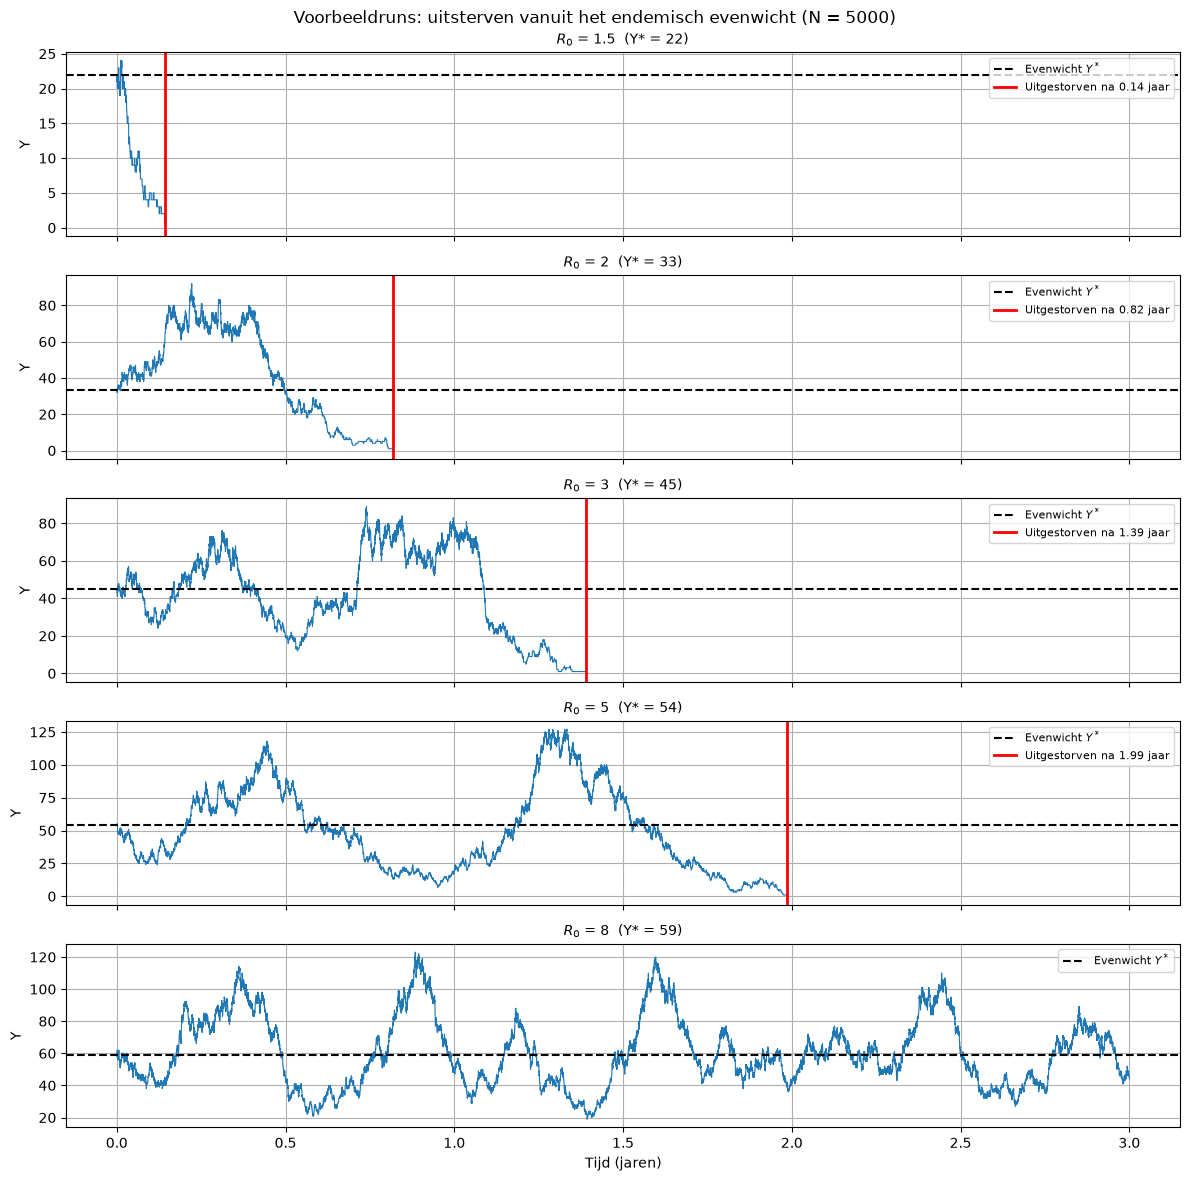

R0 = 1.5, N = 1000: 0% overleeft
R0 = 1.5, N = 2000: 0% overleeft
R0 = 1.5, N = 5000: 25% overleeft
R0 = 1.5, N = 10000: 38% overleeft
R0 = 1.5, N = 20000: 88% overleeft
R0 = 2, N = 1000: 0% overleeft
R0 = 2, N = 2000: 0% overleeft
R0 = 2, N = 5000: 0% overleeft
R0 = 2, N = 10000: 100% overleeft
R0 = 2, N = 20000: 100% overleeft
R0 = 3, N = 1000: 0% overleeft
R0 = 3, N = 2000: 0% overleeft
R0 = 3, N = 5000: 75% overleeft
R0 = 3, N = 10000: 88% overleeft
R0 = 3, N = 20000: 100% overleeft
R0 = 5, N = 1000: 0% overleeft
R0 = 5, N = 2000: 38% overleeft
R0 = 5, N = 5000: 88% overleeft
R0 = 5, N = 10000: 100% overleeft
R0 = 5, N = 20000: 100% overleeft
R0 = 8, N = 1000: 0% overleeft
R0 = 8, N = 2000: 75% overleeft
R0 = 8, N = 5000: 100% overleeft
R0 = 8, N = 10000: 100% overleeft
R0 = 8, N = 20000: 100% overleeft


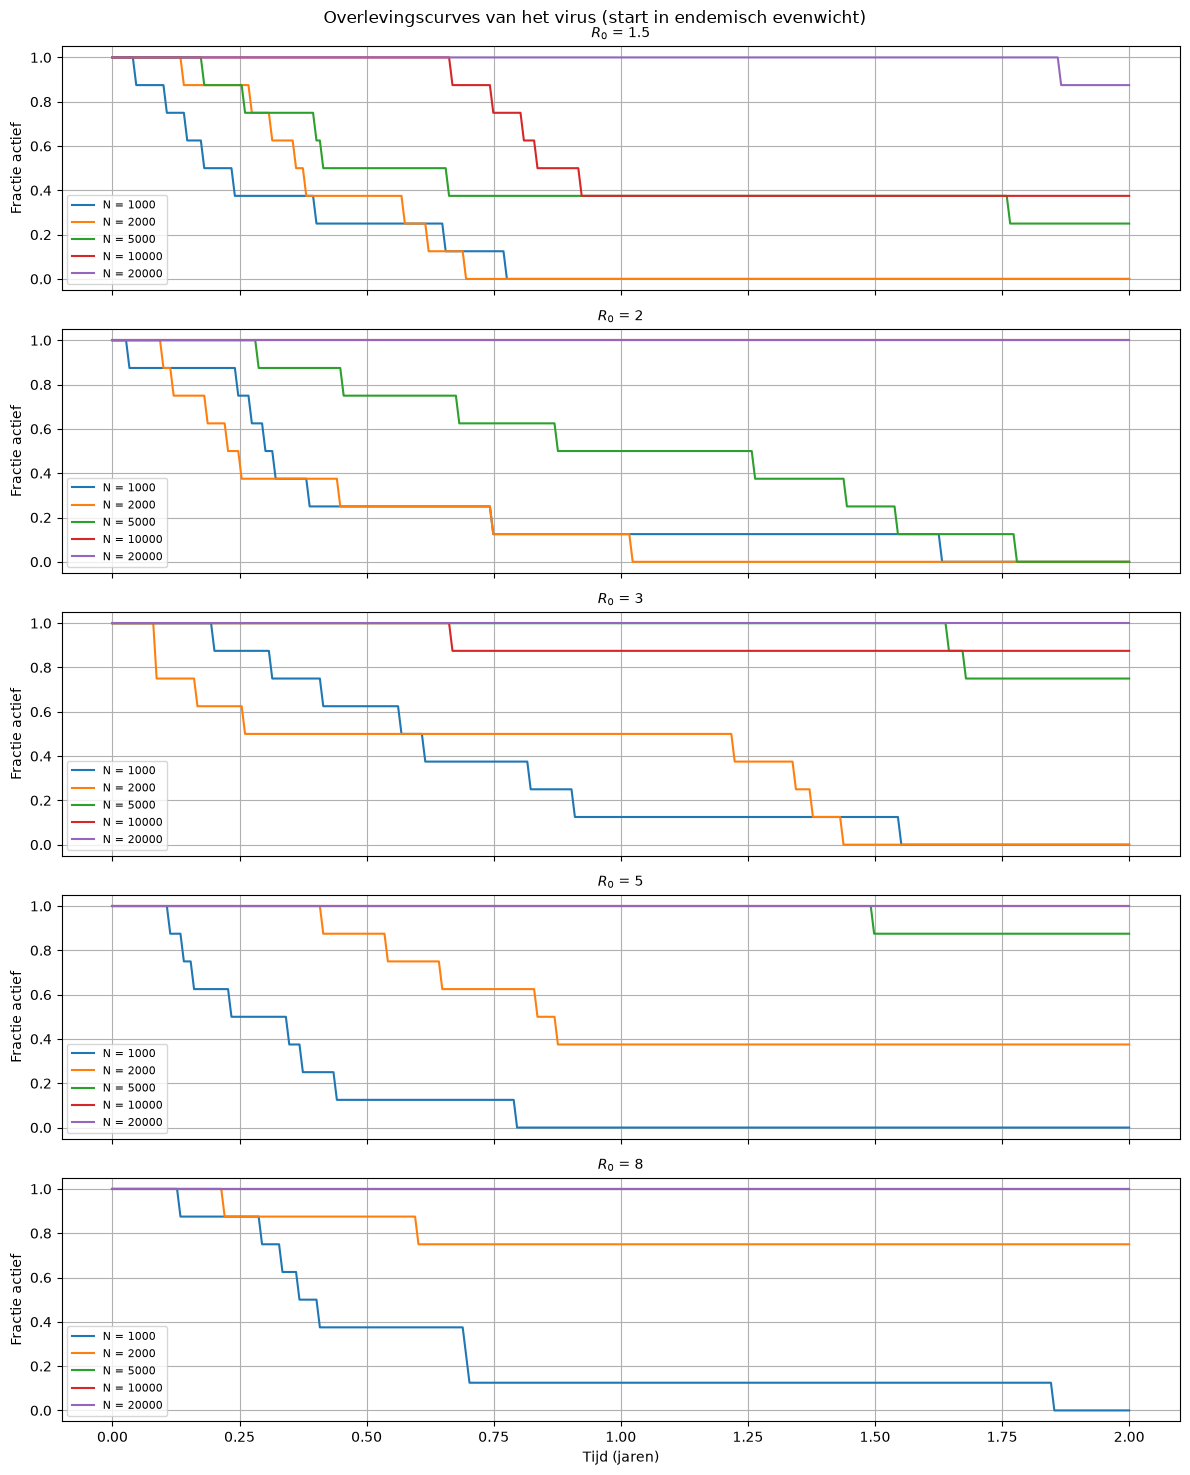

In [12]:
# Extinction events and Critical Community Size

import numpy as np
import matplotlib.pyplot as plt

# Stochastic Model

def gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max):
    # Initiële waarden
    t = 0.0
    X, Y, Z = X0, Y0, Z0
    
    # Lijsten voor de resultaten
    times = [t]
    X_history = [X]
    Y_history = [Y]
    Z_history = [Z]
    
    while t < t_max and Y > 0:
        # Bereken de rates (propensities) van elke gebeurtenis
        r1 = mu * N                  # Geboorte (X -> X + 1)
        r2 = beta * X * Y / N        # Infectie (X -> X-1, Y -> Y+1)
        r3 = gamma * Y               # Herstel (Y -> Y-1, Z -> Z+1)
        r4 = mu * X                  # Sterfte S (X -> X - 1)
        r5 = mu * Y                  # Sterfte I (Y -> Y - 1)
        r6 = mu * Z                  # Sterfte R (Z -> Z - 1)
        
        rates = [r1, r2, r3, r4, r5, r6]
        R_total = sum(rates)
        
        if R_total == 0:
            break
            
        # 1. Bepaal de tijd tot de volgende gebeurtenis (Exponentiële verdeling)
        u1 = np.random.uniform(0, 1)
        dt = -np.log(u1) / R_total
        t += dt
        
        # 2. Bepaal welke gebeurtenis plaatsvindt
        u2 = np.random.uniform(0, 1)
        probabilities = [r / R_total for r in rates]
        event = np.random.choice(6, p=probabilities)
        
        # 3. Voer de gekozen gebeurtenis uit
        if event == 0:    # Geboorte
            X += 1
        elif event == 1:  # Infectie
            X -= 1
            Y += 1
        elif event == 2:  # Herstel
            Y -= 1
            Z += 1
        elif event == 3:  # Sterfte X
            X -= 1
        elif event == 4:  # Sterfte Y
            Y -= 1
        elif event == 5:  # Sterfte Z
            Z -= 1
            
        # Bewaar de toestand
        times.append(t)
        X_history.append(X)
        Y_history.append(Y)
        Z_history.append(Z)
        
    return np.array(times), np.array(X_history), np.array(Y_history), np.array(Z_history)


# Parameters (zelfde als bij stochastic resonance)
gamma = 1/10
mu = 1/(2*365)

# Experiment 1: voorbeeldruns bij vaste N, één grafiek per R0 onder elkaar
# Het deterministische model blijft altijd in het evenwicht Y*, maar in het
# stochastische model kan Y in een dal van een oscillatie op 0 uitkomen.
# Omdat er geen import van buitenaf is, is het virus dan definitief weg.
N_voorbeeld = 5000
R0_voorbeeld = [1.5, 2, 3, 5, 8]
t_max_voorbeeld = 3 * 365

fig, axes = plt.subplots(len(R0_voorbeeld), 1, figsize=(12, 12), sharex=True)
for ax, R0_i in zip(axes, R0_voorbeeld):
    beta_i = R0_i * gamma
    # Start in het endemisch evenwicht
    X_eq_i = N_voorbeeld * (gamma + mu) / beta_i
    Y_eq_i = mu * N_voorbeeld * (N_voorbeeld - X_eq_i) / (beta_i * X_eq_i)
    X0_i = int(round(X_eq_i))
    Y0_i = max(1, int(round(Y_eq_i)))
    Z0_i = N_voorbeeld - X0_i - Y0_i

    t_s, X_s, Y_s, Z_s = gillespie_sir(N_voorbeeld, beta_i, gamma, mu, X0_i, Y0_i, Z0_i, t_max_voorbeeld)

    ax.plot(t_s / 365, Y_s, lw=0.8)
    ax.axhline(Y_eq_i, color='k', ls='--', label='Evenwicht $Y^*$')
    # Moment van uitsterven markeren
    if t_s[-1] < t_max_voorbeeld:
        ax.axvline(t_s[-1] / 365, color='red', lw=2, label=f'Uitgestorven na {t_s[-1]/365:.2f} jaar')
    ax.set_ylabel('Y')
    ax.set_title(f'$R_0$ = {R0_i}  (Y* = {Y_eq_i:.0f})', fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True)
axes[-1].set_xlabel('Tijd (jaren)')
plt.suptitle(f'Voorbeeldruns: uitsterven vanuit het endemisch evenwicht (N = {N_voorbeeld})')
plt.tight_layout()
plt.show()


# Experiment 2: raster over N en R0 -> wanneer sterft het virus uit?
# Voor elke combinatie draaien we meerdere runs vanuit het evenwicht en
# slaan we de uitstervingstijd op (inf = overleefd tot t_max).
R0_grid = [1.5, 2, 3, 5, 8]
N_grid = [1000, 2000, 5000, 10000, 20000]
n_herh = 8                    # runs per combinatie (meer = nauwkeuriger, maar trager)
t_max_ccs = 2 * 365

# t_ext[i, j, k] = uitstervingstijd voor R0_grid[i], N_grid[j], run k
t_ext = np.full((len(R0_grid), len(N_grid), n_herh), np.inf)

for i, R0_i in enumerate(R0_grid):
    beta_i = R0_i * gamma
    for j, N_i in enumerate(N_grid):
        X_eq_i = N_i * (gamma + mu) / beta_i
        Y_eq_i = mu * N_i * (N_i - X_eq_i) / (beta_i * X_eq_i)
        X0_i = int(round(X_eq_i))
        Y0_i = max(1, int(round(Y_eq_i)))
        Z0_i = N_i - X0_i - Y0_i
        for k in range(n_herh):
            t_s, X_s, Y_s, Z_s = gillespie_sir(N_i, beta_i, gamma, mu, X0_i, Y0_i, Z0_i, t_max_ccs)
            if t_s[-1] < t_max_ccs:
                t_ext[i, j, k] = t_s[-1]
        print(f"R0 = {R0_i}, N = {N_i}: {np.mean(np.isinf(t_ext[i, j]))*100:.0f}% overleeft")

# Kans dat het virus t_max overleeft
P_overleven = np.mean(np.isinf(t_ext), axis=2)

# Overlevingscurves: fractie runs waarin het virus nog bestaat, per R0 onder elkaar
t_as = np.linspace(0, t_max_ccs, 300)
fig, axes = plt.subplots(len(R0_grid), 1, figsize=(12, 3 * len(R0_grid)), sharex=True)
for i, (ax, R0_i) in enumerate(zip(axes, R0_grid)):
    for j, N_i in enumerate(N_grid):
        nog_actief = np.mean(t_ext[i, j][:, None] > t_as[None, :], axis=0)
        ax.plot(t_as / 365, nog_actief, lw=1.5, label=f'N = {N_i}')
    ax.set_ylabel('Fractie actief')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'$R_0$ = {R0_i}', fontsize=10)
    ax.grid(True)
    ax.legend(fontsize=8, loc='lower left')
axes[-1].set_xlabel('Tijd (jaren)')
plt.suptitle('Overlevingscurves van het virus (start in endemisch evenwicht)')
plt.tight_layout()
plt.show()